# Figure 4 Main + Supplementary Figure Builder

This notebook assumes the previous explanation-reliability analysis has already been run.

It **does not retrain Logistic Regression, Linear SVM, or XGBoost**.  
It only reads the saved result tables from `../results/Figure4/` and generates:

- Main Figure 4: `../figures/Figure4/Figure4_explanation_reliability_170mm_from_results.png/pdf`
- Supplementary Figure: `../figures/Supplementary_Figures/Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.png/pdf`

Run this notebook from the `OpenXAI/code/` folder.


In [1]:
# ============================================================
# 0. Imports and publication settings
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

try:
    from IPython.display import display
except Exception:
    display = print

# PNAS-style sizing:
# 170 mm = 6.69 inches, close to 2-column width.
FIG_WIDTH_MM = 170
MAIN_FIG_HEIGHT_MM = 145
SUPP_FIG_HEIGHT_MM = 165

TOP_K = 20

RESULT_DIR = Path("../results/Figure4")
MAIN_FIG_DIR = Path("../figures/Figure4")
SUPP_FIG_DIR = Path("../figures/Supplementary_Figures")

MAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)
SUPP_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    }
)

print("RESULT_DIR:", RESULT_DIR.resolve())
print("MAIN_FIG_DIR:", MAIN_FIG_DIR.resolve())
print("SUPP_FIG_DIR:", SUPP_FIG_DIR.resolve())


RESULT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4
MAIN_FIG_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4
SUPP_FIG_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Supplementary_Figures


In [2]:
# ============================================================
# 1. Load saved result tables from previous analysis
# ============================================================

required_files = {
    "stability_df": RESULT_DIR / "figure4_panelA_stability.csv",
    "fer_repeats_df": RESULT_DIR / "figure4_panelB_false_explanation_rate_repeats.csv",
    "fer_summary_df": RESULT_DIR / "figure4_panelB_false_explanation_rate_summary.csv",
    "agreement_mat": RESULT_DIR / "figure4_panelC_method_agreement_jaccard.csv",
    "method_top_features_df": RESULT_DIR / "figure4_panelC_top_features_by_method.csv",
    "domain_summary_df": RESULT_DIR / "figure4_panelD_domain_composition.csv",
    "noise_top_features_df": RESULT_DIR / "figure4_noise_injection_top_features.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Some Figure 4 result files are missing. "
        "Run the previous analysis notebook/script first.\n\nMissing files:\n"
        + "\n".join(missing)
    )

stability_df = pd.read_csv(required_files["stability_df"])
fer_repeats_df = pd.read_csv(required_files["fer_repeats_df"])
fer_summary_df = pd.read_csv(required_files["fer_summary_df"])
agreement_mat = pd.read_csv(required_files["agreement_mat"], index_col=0)
method_top_features_df = pd.read_csv(required_files["method_top_features_df"])
domain_summary_df = pd.read_csv(required_files["domain_summary_df"])
noise_top_features_df = pd.read_csv(required_files["noise_top_features_df"])

print("Loaded tables:")
for name, path in required_files.items():
    obj = globals()[name]
    print(f"- {name}: {obj.shape}  <- {path.name}")

display(stability_df)
display(fer_summary_df)
display(agreement_mat)


Loaded tables:
- stability_df: (3, 4)  <- figure4_panelA_stability.csv
- fer_repeats_df: (9, 5)  <- figure4_panelB_false_explanation_rate_repeats.csv
- fer_summary_df: (3, 4)  <- figure4_panelB_false_explanation_rate_summary.csv
- agreement_mat: (4, 4)  <- figure4_panelC_method_agreement_jaccard.csv
- method_top_features_df: (80, 4)  <- figure4_panelC_top_features_by_method.csv
- domain_summary_df: (21, 3)  <- figure4_panelD_domain_composition.csv
- noise_top_features_df: (180, 7)  <- figure4_noise_injection_top_features.csv


,model,stability_mean,stability_std,n_pairwise_fold_comparisons
0,Logistic Regression,0.427602,0.076525,10
1,Linear SVM,0.427159,0.071459,10
2,XGBoost,0.416535,0.065411,10


,model,fer_mean,fer_std,mean_noise_count
0,Linear SVM,0.0,0.0,0.0
1,Logistic Regression,0.0,0.0,0.0
2,XGBoost,0.0,0.0,0.0


,LR coef.,SVM coef.,XGB gain,XGB perm.
LR coef.,1.000000,0.428571,0.081081,0.052632
SVM coef.,0.428571,1.000000,0.081081,0.025641
XGB gain,0.081081,0.081081,1.000000,0.176471
XGB perm.,0.052632,0.025641,0.176471,1.000000


In [3]:
# ============================================================
# 2. Helper functions for plotting
# ============================================================

plot_models = ["Logistic Regression", "Linear SVM", "XGBoost"]
plot_model_labels = ["Logistic\nRegression", "Linear\nSVM", "XGBoost"]

domain_order = [
    "Renal",
    "Cardiovascular",
    "Respiratory",
    "Metabolic / acid-base",
    "Hematologic",
    "Neurological",
    "Static / demographic",
    "Measurement process",
    "Noise",
    "Other clinical",
]

def panel_label(ax, label, x=-0.18, y=1.11):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
    )

def format_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

def safe_get_value(df, row_col, row_value, value_col, default=np.nan):
    vals = df.loc[df[row_col] == row_value, value_col]
    if len(vals) == 0:
        return default
    return float(vals.iloc[0])

def build_domain_pivot(df, model_col="model", domain_col="domain", value_col="proportion"):
    pivot = (
        df.pivot_table(
            index=model_col,
            columns=domain_col,
            values=value_col,
            aggfunc="sum",
            fill_value=0,
        )
    )
    for domain in domain_order:
        if domain not in pivot.columns:
            pivot[domain] = 0.0
    return pivot[domain_order]


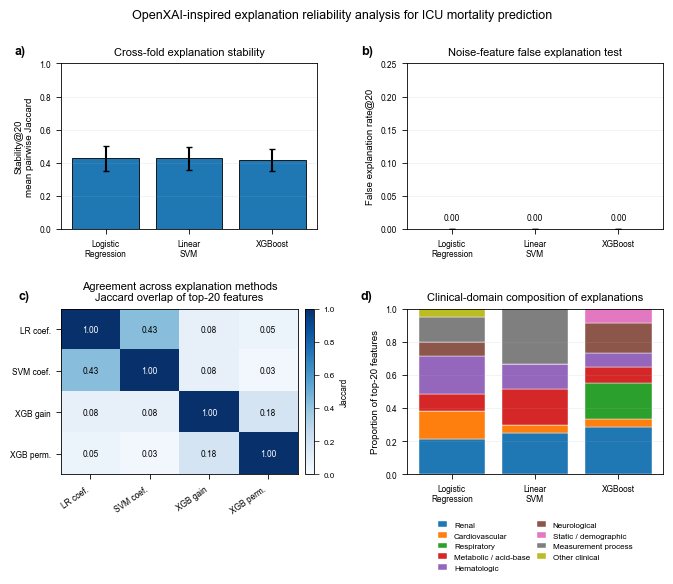

Saved main figure:
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4\Figure4_explanation_reliability_170mm_from_results.png
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4\Figure4_explanation_reliability_170mm_from_results.pdf


In [4]:
# ============================================================
# 3. Main Figure 4 from saved results
# ============================================================

fig_w = FIG_WIDTH_MM / 25.4
fig_h = MAIN_FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.48,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

x = np.arange(len(plot_models))

# ----------------------------
# a) Stability
# ----------------------------
stab_vals = [
    safe_get_value(stability_df, "model", m, "stability_mean")
    for m in plot_models
]
stab_err = [
    safe_get_value(stability_df, "model", m, "stability_std", default=0)
    for m in plot_models
]

axA.bar(x, stab_vals, yerr=stab_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axA.set_xticks(x)
axA.set_xticklabels(plot_model_labels)
axA.set_ylim(0, 1)
axA.set_ylabel(f"Stability@{TOP_K}\nmean pairwise Jaccard")
axA.set_title("Cross-fold explanation stability")
axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")

# ----------------------------
# b) False Explanation Rate
# ----------------------------
fer_vals = [
    safe_get_value(fer_summary_df, "model", m, "fer_mean")
    for m in plot_models
]
fer_err = [
    safe_get_value(fer_summary_df, "model", m, "fer_std", default=0)
    for m in plot_models
]

upper_b = max(0.25, min(1.0, np.nanmax(fer_vals) + 0.15))

axB.bar(x, fer_vals, yerr=fer_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axB.set_xticks(x)
axB.set_xticklabels(plot_model_labels)
axB.set_ylim(0, upper_b)
axB.set_ylabel(f"False explanation rate@{TOP_K}")
axB.set_title("Noise-feature false explanation test")
axB.grid(axis="y", alpha=0.25, linewidth=0.4)

for xi, val in zip(x, fer_vals):
    if np.isfinite(val):
        axB.text(xi, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=6)

panel_label(axB, "b)")

# ----------------------------
# c) Agreement heatmap
# ----------------------------
methods = list(agreement_mat.index)
im = axC.imshow(agreement_mat.values, vmin=0, vmax=1, aspect="auto", cmap="Blues")

axC.set_xticks(np.arange(len(methods)))
axC.set_yticks(np.arange(len(methods)))
axC.set_xticklabels(methods, rotation=35, ha="right")
axC.set_yticklabels(methods)
axC.set_title(f"Agreement across explanation methods\nJaccard overlap of top-{TOP_K} features")

for i in range(len(methods)):
    for j in range(len(methods)):
        val = agreement_mat.values[i, j]
        text_color = "white" if val > 0.55 else "black"
        axC.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_color)

cbar = fig.colorbar(im, ax=axC, fraction=0.046, pad=0.03)
cbar.ax.tick_params(labelsize=5.8, width=0.5)
cbar.set_label("Jaccard", fontsize=6)

panel_label(axC, "c)")

# ----------------------------
# d) Domain composition
# ----------------------------
domain_pivot = build_domain_pivot(domain_summary_df)
domain_pivot = domain_pivot.reindex(plot_models).fillna(0)

bottom = np.zeros(len(plot_models))
for domain in domain_order:
    vals = domain_pivot[domain].values
    if np.all(vals == 0):
        continue
    axD.bar(
        x,
        vals,
        bottom=bottom,
        label=domain,
        linewidth=0.3,
        edgecolor="white",
    )
    bottom += vals

axD.set_xticks(x)
axD.set_xticklabels(plot_model_labels)
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.set_title("Clinical-domain composition of explanations")
axD.grid(axis="y", alpha=0.25, linewidth=0.4)

axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=2,
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
)

panel_label(axD, "d)")

for ax in [axA, axB, axC, axD]:
    format_axes(ax)

fig.suptitle(
    "OpenXAI-inspired explanation reliability analysis for ICU mortality prediction",
    fontsize=9,
    y=0.995,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.18,
)

main_png = MAIN_FIG_DIR / "Figure4_explanation_reliability_170mm_from_results.png"
main_pdf = MAIN_FIG_DIR / "Figure4_explanation_reliability_170mm_from_results.pdf"

fig.savefig(main_png, dpi=600, bbox_inches="tight")
fig.savefig(main_pdf, bbox_inches="tight")

plt.show()

print("Saved main figure:")
print(main_png.resolve())
print(main_pdf.resolve())


In [5]:
# ============================================================
# 4. Build supplementary feature-support and domain tables
# ============================================================

# Feature support matrix across explanation methods
support_df = method_top_features_df.copy()

# Lower rank is better. Use min rank per feature across methods for sorting.
rank_summary = (
    support_df.groupby("feature", as_index=False)
    .agg(
        n_methods=("method", "nunique"),
        best_rank=("rank", "min"),
        domain=("domain", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
    )
)

# Use features supported by >=2 methods first; if too few, keep top 35 by support and best rank.
rank_summary = rank_summary.sort_values(
    ["n_methods", "best_rank"],
    ascending=[False, True],
)

selected_features = rank_summary.loc[rank_summary["n_methods"] >= 2, "feature"].tolist()
if len(selected_features) < 8:
    selected_features = rank_summary.head(35)["feature"].tolist()
else:
    selected_features = selected_features[:35]

support_matrix = pd.DataFrame(
    0,
    index=selected_features,
    columns=list(pd.unique(support_df["method"])),
)

for _, row in support_df.iterrows():
    feat = row["feature"]
    method = row["method"]
    if feat in support_matrix.index and method in support_matrix.columns:
        support_matrix.loc[feat, method] = 1

# Add summary columns for export
support_export = rank_summary.set_index("feature").loc[selected_features].reset_index()
support_export.to_csv(
    RESULT_DIR / "supplementary_figure4_feature_support_summary.csv",
    index=False,
)
support_matrix.to_csv(
    RESULT_DIR / "supplementary_figure4_feature_support_matrix.csv",
)

# Domain composition across explanation methods
method_domain = (
    method_top_features_df.groupby(["method", "domain"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
method_domain["proportion"] = method_domain.groupby("method")["count"].transform(lambda s: s / s.sum())
method_domain.to_csv(
    RESULT_DIR / "supplementary_figure4_method_domain_composition.csv",
    index=False,
)

display(support_export.head(20))
display(method_domain.head(20))


,feature,n_methods,best_rank,domain
0,GCS_last,3,1,Neurological
1,PaCO2_count,3,6,Measurement process
2,Urine_mean,3,8,Renal
3,WBC_mean,2,1,Hematologic
4,pH_median,2,1,Metabolic / acid-base
5,BUN_last,2,2,Renal
6,WBC_max,2,2,Hematologic
7,static_Age,2,2,Static / demographic
8,GCS_std,2,3,Neurological
9,Platelets_min,2,3,Hematologic


,method,domain,count,proportion
0,LR coef.,Cardiovascular,3,0.15
1,LR coef.,Hematologic,4,0.20
2,LR coef.,Measurement process,4,0.20
3,LR coef.,Metabolic / acid-base,2,0.10
4,LR coef.,Neurological,2,0.10
5,LR coef.,Other clinical,1,0.05
6,LR coef.,Renal,4,0.20
7,SVM coef.,Cardiovascular,1,0.05
8,SVM coef.,Hematologic,3,0.15
9,SVM coef.,Measurement process,8,0.40


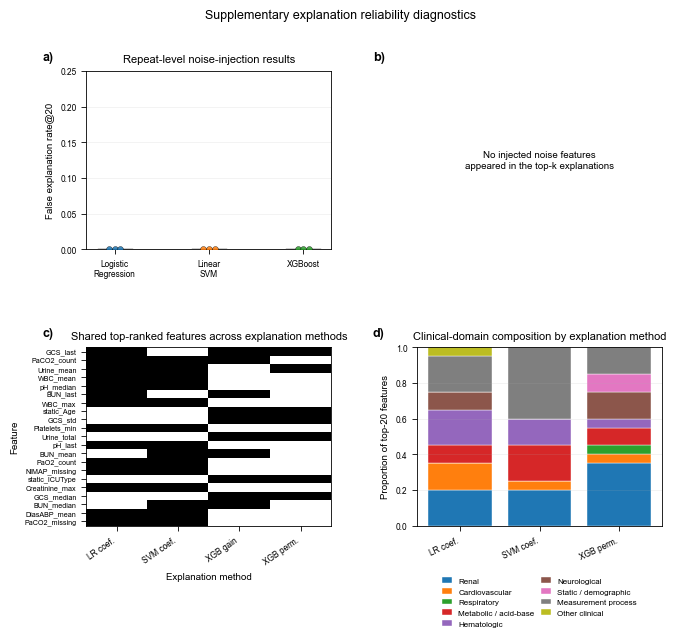

Saved supplementary figure:
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Supplementary_Figures\Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.png
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Supplementary_Figures\Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.pdf


In [6]:
# ============================================================
# 5. Supplementary Figure S4 from saved results
# ============================================================

fig_w = FIG_WIDTH_MM / 25.4
fig_h = SUPP_FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.55,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# ----------------------------
# a) FER repeat-level values
# ----------------------------
x = np.arange(len(plot_models))

for i, model in enumerate(plot_models):
    vals = fer_repeats_df.loc[
        fer_repeats_df["model"] == model,
        "false_explanation_rate",
    ].values

    if len(vals) == 0:
        continue

    jitter = np.linspace(-0.06, 0.06, len(vals)) if len(vals) > 1 else np.array([0])
    axA.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        s=18,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        zorder=3,
    )

    mean_val = np.mean(vals)
    axA.plot([i - 0.18, i + 0.18], [mean_val, mean_val], color="black", linewidth=1.0)

axA.set_xticks(x)
axA.set_xticklabels(plot_model_labels)
axA.set_ylim(0, max(0.25, min(1.0, fer_repeats_df["false_explanation_rate"].max() + 0.15)))
axA.set_ylabel(f"False explanation rate@{TOP_K}")
axA.set_title("Repeat-level noise-injection results")
axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")

# ----------------------------
# b) Rank distribution of noise features
# ----------------------------
noise_rank_df = noise_top_features_df.loc[
    noise_top_features_df["is_noise"].astype(bool)
].copy()

if len(noise_rank_df) == 0:
    axB.text(
        0.5,
        0.5,
        "No injected noise features\nappeared in the top-k explanations",
        transform=axB.transAxes,
        ha="center",
        va="center",
        fontsize=7,
    )
    axB.set_axis_off()
else:
    rank_bins = [1, 5, 10, 15, 20]
    # Use exact ranks as histogram bins from 1 to TOP_K.
    for model in plot_models:
        ranks = noise_rank_df.loc[noise_rank_df["model"] == model, "rank"].values
        if len(ranks) == 0:
            continue
        axB.hist(
            ranks,
            bins=np.arange(1, TOP_K + 2) - 0.5,
            histtype="step",
            linewidth=1.0,
            label=model,
        )

    axB.set_xlim(0.5, TOP_K + 0.5)
    axB.set_xticks([1, 5, 10, 15, 20])
    axB.set_xlabel("Rank among top-k features")
    axB.set_ylabel("Noise-feature count")
    axB.set_title("Where false explanation features appear")
    axB.grid(axis="y", alpha=0.25, linewidth=0.4)
    axB.legend(frameon=False, loc="upper right")

panel_label(axB, "b)")

# ----------------------------
# c) Feature support matrix
# ----------------------------
im = axC.imshow(
    support_matrix.values,
    vmin=0,
    vmax=1,
    aspect="auto",
    cmap="Greys",
)

axC.set_xticks(np.arange(support_matrix.shape[1]))
axC.set_xticklabels(support_matrix.columns, rotation=35, ha="right")
axC.set_yticks(np.arange(support_matrix.shape[0]))

# Keep y labels readable by truncating very long feature names.
yticks = []
for feat in support_matrix.index:
    feat_str = str(feat)
    if len(feat_str) > 26:
        feat_str = feat_str[:23] + "..."
    yticks.append(feat_str)

axC.set_yticklabels(yticks, fontsize=5.2)
axC.set_title("Shared top-ranked features across explanation methods")
axC.set_xlabel("Explanation method")
axC.set_ylabel("Feature")

panel_label(axC, "c)")

# ----------------------------
# d) Domain composition across methods
# ----------------------------
method_domain_pivot = build_domain_pivot(
    method_domain,
    model_col="method",
    domain_col="domain",
    value_col="proportion",
)

method_order = [m for m in ["LR coef.", "SVM coef.", "XGB SHAP", "XGB perm."] if m in method_domain_pivot.index]
if not method_order:
    method_order = list(method_domain_pivot.index)

method_domain_pivot = method_domain_pivot.reindex(method_order).fillna(0)

x2 = np.arange(len(method_order))
bottom = np.zeros(len(method_order))

for domain in domain_order:
    vals = method_domain_pivot[domain].values
    if np.all(vals == 0):
        continue
    axD.bar(
        x2,
        vals,
        bottom=bottom,
        label=domain,
        linewidth=0.3,
        edgecolor="white",
    )
    bottom += vals

axD.set_xticks(x2)
axD.set_xticklabels(method_order, rotation=25, ha="right")
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.set_title("Clinical-domain composition by explanation method")
axD.grid(axis="y", alpha=0.25, linewidth=0.4)

axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=2,
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
)

panel_label(axD, "d)")

for ax in [axA, axB, axC, axD]:
    format_axes(ax)

fig.suptitle(
    "Supplementary explanation reliability diagnostics",
    fontsize=9,
    y=0.995,
)

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.90,
    bottom=0.20,
)

supp_png = SUPP_FIG_DIR / "Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.png"
supp_pdf = SUPP_FIG_DIR / "Supplementary_FigureS4_explanation_reliability_diagnostics_170mm.pdf"

fig.savefig(supp_png, dpi=600, bbox_inches="tight")
fig.savefig(supp_pdf, bbox_inches="tight")

plt.show()

print("Saved supplementary figure:")
print(supp_png.resolve())
print(supp_pdf.resolve())


## Figure legend drafts

**Main Figure 4. OpenXAI-inspired explanation reliability analysis for ICU mortality prediction.**  
**a)** Cross-fold explanation stability measured as mean pairwise Jaccard similarity among top-20 features across five cross-validation folds.  
**b)** False explanation rate after random noise feature injection, defined as the proportion of injected noise features appearing among the top-20 explanation features.  
**c)** Agreement across explanation methods, measured as top-20 Jaccard overlap among logistic regression coefficients, linear SVM coefficients, XGBoost SHAP, and XGBoost permutation importance.  
**d)** Clinical-domain composition of top-ranked explanation features, showing whether explanations emphasize physiological clinical domains, measurement-process variables, or injected noise features.

**Supplementary Figure S4. Detailed explanation reliability diagnostics.**  
**a)** Repeat-level false explanation rates from the random noise injection experiment.  
**b)** Rank distribution of injected noise features that appeared within the top-20 explanations.  
**c)** Shared top-ranked feature support matrix across explanation methods.  
**d)** Clinical-domain composition of top-ranked features for each explanation method.
